In [25]:
import pandas as pd

columns = [
    'unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

columns

['unit_number',
 'time_in_cycles',
 'op_setting_1',
 'op_setting_2',
 'op_setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
train_file_path = '/content/drive/MyDrive/CMAPSSData/train_FD001.txt'
test_file_path = '/content/drive/MyDrive/CMAPSSData/test_FD001.txt'
ground_truth_file_path = '/content/drive/MyDrive/CMAPSSData/RUL_FD001.txt'

train_df = pd.read_csv(
    train_file_path, 
    sep=r'\s+',       
    header=None,       
    names=columns     
)

test_df = pd.read_csv(
    test_file_path, 
    sep=r'\s+',        
    header=None,      
    names=columns     
)

true_rul = pd.read_csv(
    ground_truth_file_path, 
    sep=r'\s+',       
    header=None,       
    names=['RUL']     
)

In [28]:
train_df.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [29]:
test_df.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [30]:
true_rul.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [31]:
max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max() # max life cycles of each engine
max_cycles

,time_in_cycles
unit_number,
1,192
2,287
3,179
4,189
5,269
...,...
96,336
97,202
98,156


In [32]:
train_df = train_df.merge(max_cycles.to_frame(name='max_cycles'), left_on='unit_number', right_index=True)
train_df

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,200
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,200
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,200
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,200


In [33]:
# Remaining Useful Life = Max Cycles - Current Cycle
train_df['RUL'] = train_df['max_cycles'] - train_df['time_in_cycles']
train_df = train_df.drop('max_cycles', axis=1)
train_df

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


In [34]:
std_devs = train_df.std()
std_devs



,0
unit_number,2.922763e+01
time_in_cycles,6.888099e+01
op_setting_1,2.187313e-03
op_setting_2,2.930621e-04
op_setting_3,0.000000e+00
sensor_1,6.537152e-11
sensor_2,5.000533e-01
sensor_3,6.131150e+00
sensor_4,9.000605e+00
sensor_5,3.394700e-12


In [35]:
useless_columns = std_devs[std_devs < 0.01].index
useless_columns

Index(['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_5',
       'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'],
      dtype='object')

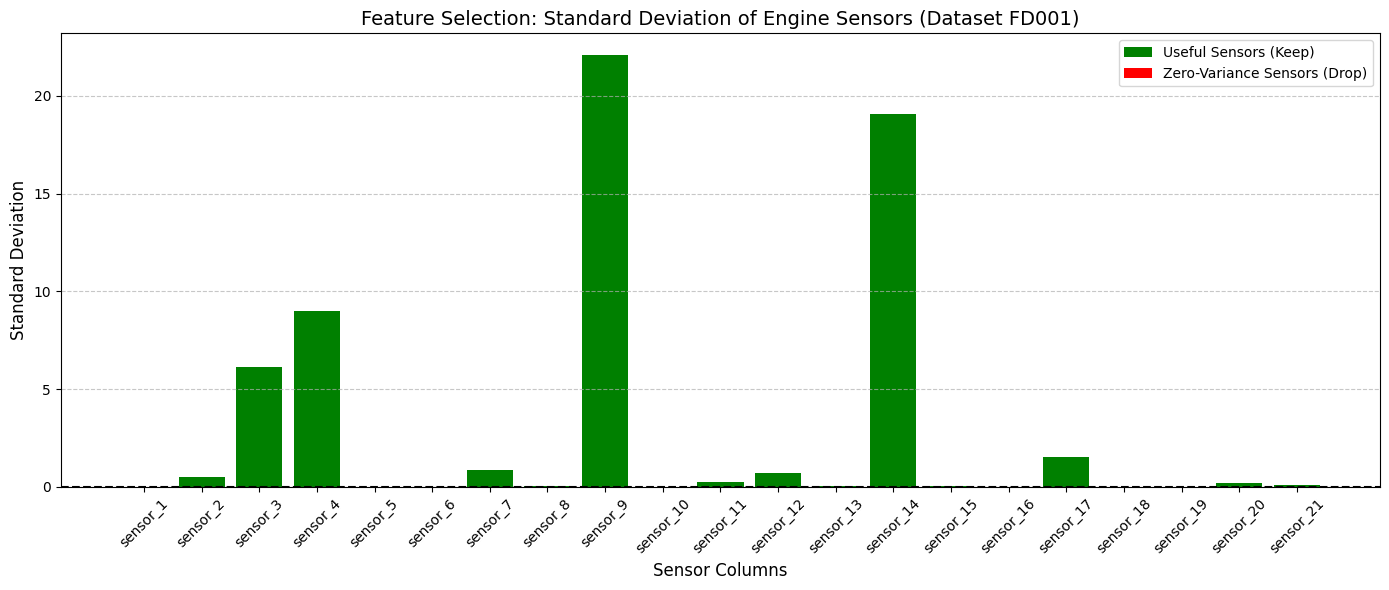

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

sensor_columns = [f'sensor_{i}' for i in range(1, 22)]
sensors_only = train_df[sensor_columns]

std_devs = sensors_only.std()

colors = ['red' if std < 0.01 else 'green' for std in std_devs]

plt.figure(figsize=(14, 6))
bars = plt.bar(std_devs.index, std_devs.values, color=colors)

plt.title('Feature Selection: Standard Deviation of Engine Sensors (Dataset FD001)', fontsize=14)
plt.xlabel('Sensor Columns', fontsize=12)
plt.ylabel('Standard Deviation', fontsize=12)
plt.xticks(rotation=45)

plt.axhline(y=0.01, color='black', linestyle='--', label='Zero-Variance Threshold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Useful Sensors (Keep)'),
                   Patch(facecolor='red', label='Zero-Variance Sensors (Drop)')]
plt.legend(handles=legend_elements)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

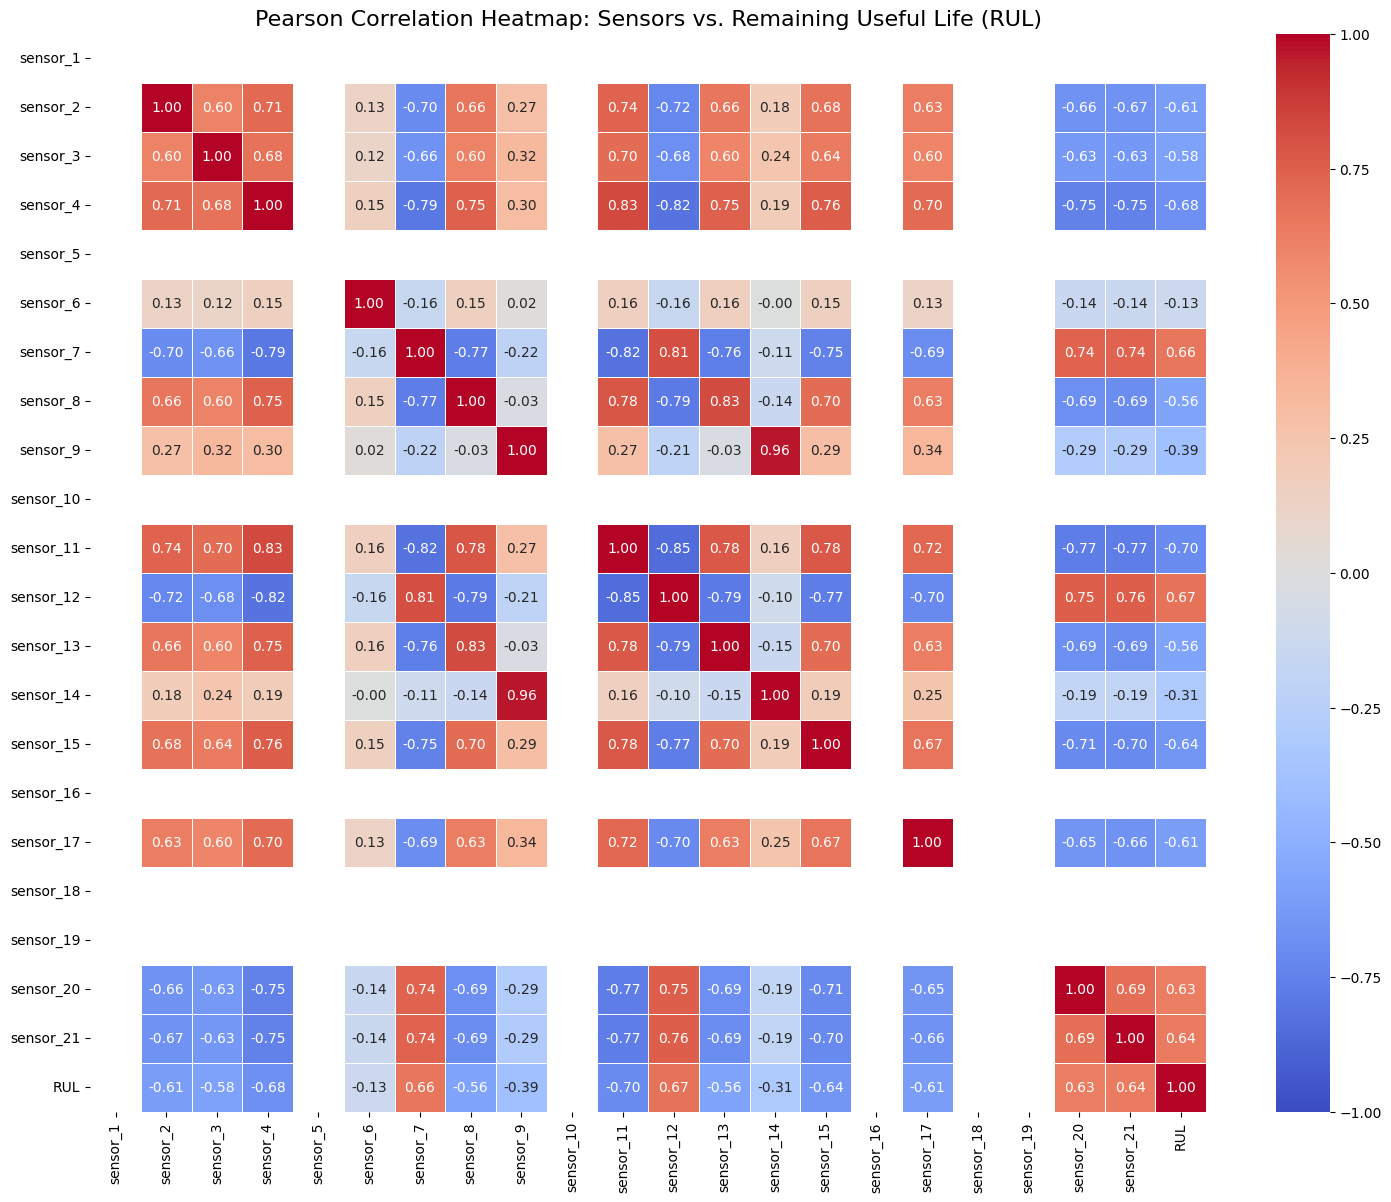

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

columns_for_corr = [f'sensor_{i}' for i in range(1, 22)] + ['RUL']
data_for_corr = train_df[columns_for_corr]

correlation_matrix = data_for_corr.corr()

plt.figure(figsize=(18, 14)) 
sns.heatmap(correlation_matrix, 
            annot=True,          
            cmap='coolwarm',    
            fmt='.2f',          
            linewidths=0.5,      
            vmin=-1, vmax=1)    

plt.title('Pearson Correlation Heatmap: Sensors vs. Remaining Useful Life (RUL)', fontsize=16)
plt.show()

In [38]:
useless_columns = list(useless_columns)
useless_columns.append('sensor_9') #shows high corelation with sensor 14
useless_columns

['op_setting_1',
 'op_setting_2',
 'op_setting_3',
 'sensor_1',
 'sensor_5',
 'sensor_6',
 'sensor_10',
 'sensor_16',
 'sensor_18',
 'sensor_19',
 'sensor_9']

In [39]:
train_df = train_df.drop(useless_columns, axis=1)
test_df = test_df.drop(useless_columns, axis=1)

In [40]:
X_train = train_df.drop(['unit_number', 'time_in_cycles', 'RUL'], axis=1)
y_train = train_df['RUL']

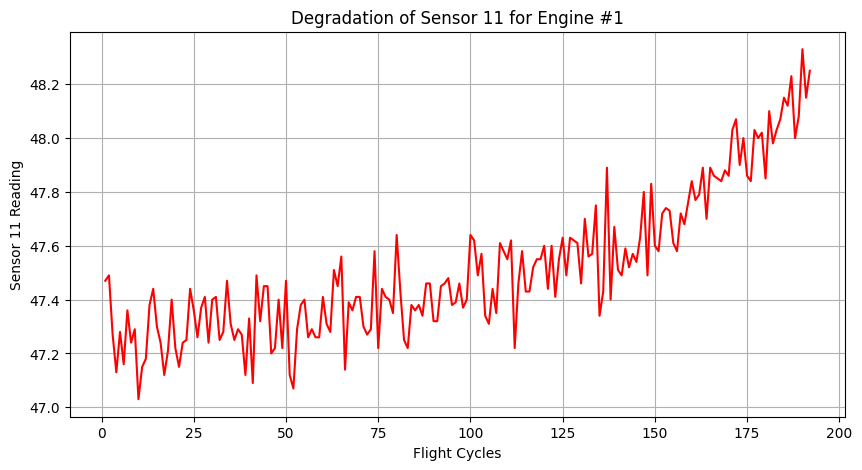

In [41]:
engine_1_data = train_df[train_df['unit_number'] == 1]

plt.figure(figsize=(10, 5))
plt.plot(engine_1_data['time_in_cycles'], engine_1_data['sensor_11'], color='red')
plt.title('Degradation of Sensor 11 for Engine #1')
plt.xlabel('Flight Cycles')
plt.ylabel('Sensor 11 Reading')
plt.grid(True)
plt.show()

In [42]:
test_last_cycle = test_df.groupby('unit_number').last().reset_index()
test_last_cycle


,unit_number,time_in_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,31,642.58,1581.22,1398.91,554.42,2388.08,47.23,521.79,2388.06,8130.11,8.4024,393,38.81,23.3552
1,2,49,642.55,1586.59,1410.83,553.52,2388.10,47.67,521.74,2388.09,8126.90,8.4505,391,38.81,23.2618
2,3,126,642.88,1589.75,1418.89,552.59,2388.16,47.88,520.83,2388.14,8131.46,8.4119,395,38.93,23.2740
3,4,106,642.78,1594.53,1406.88,552.64,2388.13,47.65,521.88,2388.11,8133.64,8.4634,395,38.58,23.2581
4,5,98,642.27,1589.94,1419.36,553.29,2388.10,47.46,521.00,2388.15,8125.74,8.4362,394,38.75,23.4117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,97,642.30,1590.88,1397.94,553.99,2388.03,47.14,522.30,2388.01,8148.24,8.4110,391,38.96,23.4606
96,97,134,642.59,1582.96,1410.92,554.05,2388.06,47.38,521.58,2388.06,8155.48,8.4500,395,38.61,23.2953
97,98,121,642.68,1599.51,1415.47,553.44,2388.13,47.66,521.53,2388.09,8146.39,8.4235,394,38.76,23.3608
98,99,97,642.00,1585.03,1397.98,554.75,2388.01,47.26,521.82,2388.02,8150.38,8.4003,391,38.95,23.3595


In [43]:
X_test = test_last_cycle.drop(['unit_number', 'time_in_cycles'], axis=1)
y_test = true_rul['RUL']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"RMSE : {rmse:.2f} cycles")
    print(f"MAE : {mae:.2f} cycles")
    print(f"R-squared : {r2:.3f}\n")



In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [47]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, lr_predictions)

--- Linear Regression ---
RMSE : 31.70 cycles
MAE : 25.38 cycles
R-squared : 0.418



In [48]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, rf_predictions)

--- Random Forest ---
RMSE : 31.50 cycles
MAE : 23.42 cycles
R-squared : 0.426

